# Regression — Exercise 3.1: Simple Linear Regression by Hand

**Course:** Introduction to Machine Learning and Applied Artificial Intelligence
**Institution:** High School of Digital Culture, ITMO University

<a href="https://colab.research.google.com/github/Mir-robotics/ITMO-Introduction-to-Machine-Learning-and-Applied-Artificial-Intelligence/blob/main/Regression/Regression_Exercise_3_1.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

Before reaching for `sklearn.linear_model.LinearRegression`, it's worth deriving
**simple linear regression** (one input feature, one output) from its closed-form
formulas. This builds intuition for what the library is actually computing under the
hood, and for what $R^2$ actually measures.

For reference, the [scikit-learn LinearRegression documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
describes the library implementation we would normally use — `LinearRegression().fit(X, y)`.


## Task

We're given observations of how long a person spent in a line ($Y$, minutes) as a
function of the number of people ahead of them in the line ($X$):

| Observation | Number of People in Line (X) | Time Spent in Store (min) (Y) |
|-------------|------------------------------|-------------------------------|
| 1           | 16                           | 29                             |
| 2           | 9                             | 27                             |
| 3           | 12                            | 34                             |
| 4           | 21                            | 43                             |
| 5           | 8                             | 25                             |
| 6           | 23                            | 45                             |
| 7           | 25                            | 62                             |
| 8           | 11                            | 29                             |
| 9           | 3                             | 7                              |
| 10          | 18                            | 29                             |

We will fit a simple linear regression model $\hat{Y} = \theta_0 + \theta_1 X$ **by
hand**, computing each intermediate quantity explicitly:

1. Sample mean $\bar{X}$
2. Sample mean $\bar{Y}$
3. Coefficients $\theta_0$ (intercept) and $\theta_1$ (slope)
4. Model accuracy via the $R^2$ statistic


## 0. Import necessary libraries


In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


## 1. Create the data

The dataset is tiny, so we enter it directly as numpy arrays rather than loading a
CSV file.


In [2]:
X = np.array([16, 9, 12, 21, 8, 23, 25, 11, 3, 18])  # Number of people in line
Y = np.array([29, 27, 34, 43, 25, 45, 62, 29, 7, 29])  # Time spent in store (min)


## 2. Sample means $\bar{X}$ and $\bar{Y}$

$$
\bar{X} = \frac{1}{n}\sum_{i=1}^{n} X_i \qquad \bar{Y} = \frac{1}{n}\sum_{i=1}^{n} Y_i
$$


In [3]:
x_mean = np.mean(X)
print(f"Sample mean X_bar: {x_mean}")


Sample mean X_bar: 14.6


In [4]:
y_mean = np.mean(Y)
print(f"Sample mean Y_bar: {y_mean}")


Sample mean Y_bar: 33.0


## 3. Regression coefficients $\theta_0$ and $\theta_1$

For simple linear regression the least-squares slope and intercept have closed-form
solutions:

$$
\theta_1 = \frac{\sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})}{\sum_{i=1}^{n} (X_i - \bar{X})^2}
\qquad
\theta_0 = \bar{Y} - \theta_1 \bar{X}
$$

$\theta_1$ is the slope: how many additional minutes of wait time we expect per
additional person in line. $\theta_0$ is the intercept: the model's predicted wait
time when there are zero people ahead.


In [5]:
theta1 = (
    sum((X[i] - x_mean) * (Y[i] - y_mean) for i in range(len(X)))
    / sum((X[i] - x_mean) ** 2 for i in range(len(X)))
)
theta0 = y_mean - theta1 * x_mean

print(f"theta0 (intercept): {round(theta0, 2)}")
print(f"theta1 (slope):     {round(theta1, 2)}")


theta0 (intercept): 6.26
theta1 (slope):     1.83


## 4. Model accuracy: $R^2$

$R^2$ compares the model's squared prediction errors against the squared errors of the
simplest possible baseline model (always predicting $\bar{Y}$):

$$
R^2 = 1 - \frac{\sum_{i=1}^{n} (Y_i - \hat{Y}_i)^2}{\sum_{i=1}^{n} (Y_i - \bar{Y})^2}
\qquad \text{where } \hat{Y}_i = \theta_0 + \theta_1 X_i
$$

$R^2 = 1$ means a perfect fit; $R^2 = 0$ means the model is no better than always
predicting the mean.


In [6]:
ss_res = sum((Y[i] - theta0 - theta1 * X[i]) ** 2 for i in range(len(X)))
ss_tot = sum((Y[i] - y_mean) ** 2 for i in range(len(Y)))
r_squared = 1 - ss_res / ss_tot

print(f"R^2: {round(r_squared, 2)}")


R^2: 0.81


## 5. Sanity check with scikit-learn

Let's confirm the hand-derived coefficients and $R^2$ match what `LinearRegression`
computes automatically.


In [7]:
model = LinearRegression().fit(X.reshape(-1, 1), Y)

print(f"sklearn intercept (theta0): {round(model.intercept_, 2)}")
print(f"sklearn slope (theta1):     {round(model.coef_[0], 2)}")
print(f"sklearn R^2 (model.score):  {round(model.score(X.reshape(-1, 1), Y), 2)}")


sklearn intercept (theta0): 6.26
sklearn slope (theta1):     1.83
sklearn R^2 (model.score):  0.81


## 6. Visualize the fit


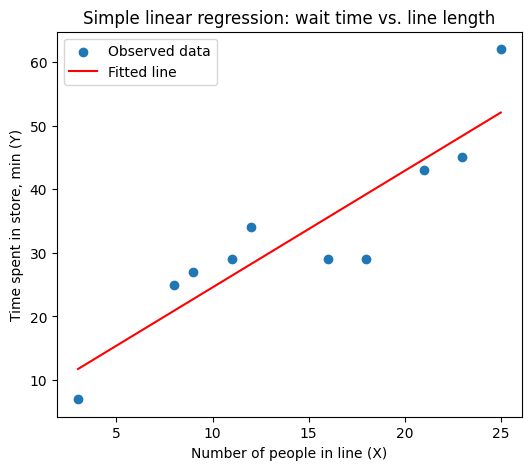

In [8]:
plt.figure(figsize=(6, 5))
plt.scatter(X, Y, label="Observed data")

x_line = np.linspace(X.min(), X.max(), 100)
y_line = theta0 + theta1 * x_line
plt.plot(x_line, y_line, color="red", label="Fitted line")

plt.xlabel("Number of people in line (X)")
plt.ylabel("Time spent in store, min (Y)")
plt.title("Simple linear regression: wait time vs. line length")
plt.legend()
plt.show()


## Summary

- With $\theta_1 \approx 1.83$, each additional person in line adds roughly 1.8
  minutes of expected wait time; the intercept $\theta_0 \approx 6.26$ represents a
  small baseline wait even with an empty line (e.g. checkout/processing time).
- $R^2 \approx 0.81$ means the linear model explains about 81% of the variance in wait
  time — a reasonably strong linear relationship for such a small, real-world-style
  sample.
- The hand-computed coefficients match scikit-learn's `LinearRegression` exactly, which
  confirms both derivations are correct and shows what the library is doing internally
  for the single-feature case.
